In [1]:
%matplotlib widget

from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import scipy.linalg as la
import skimage.io as io
import cv2


# Load image and known points

(768, 1024)


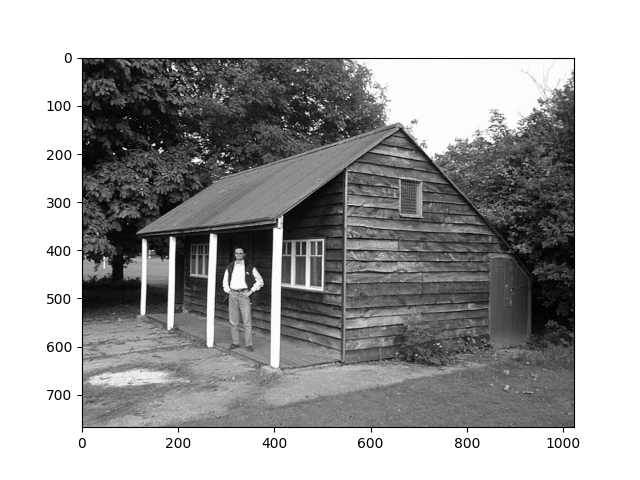

In [2]:
hut = io.imread("img/hutme.jpg")
fig, ax = plt.subplots(1, 1)
plt.gray()

ax.imshow(hut, vmin=0, vmax=255);
print(hut.shape)

## The length of segment 9 is known to be 294.3 cm

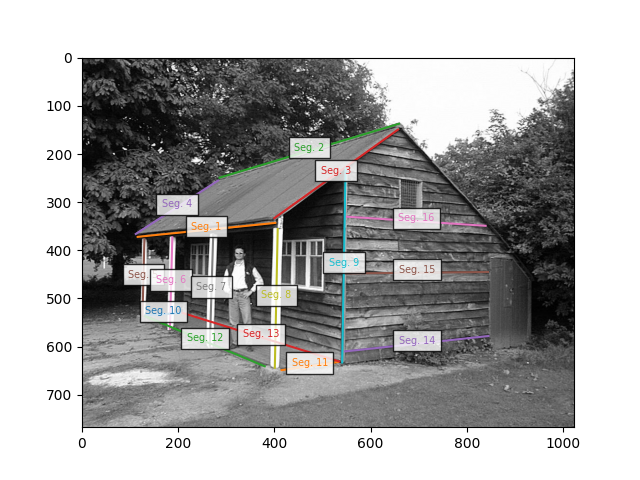

In [3]:
fig, ax = plt.subplots(1, 1)
plt.gray()
ax.imshow(hut, vmin=0, vmax=255);


points = sio.loadmat("img/points_2D.mat")["points_2D"]
lines = {}

for (x, y, l), (u, v, l_) in zip(points[::2], points[1::2]):
    assert l == l_
    ax.plot((x, u), (y, v), c=f"C{l}")
    txt = ax.text((x+u)/2, (y+v)/2, f"Seg. {l}", c=f"C{l}", horizontalalignment='center', size="x-small", va="baseline")
    txt.set_bbox({"facecolor": "white", "alpha": 0.8})
    lines[l] = np.array([(x, y, 1), (u, v, 1)])

# Lets measure the horizon line

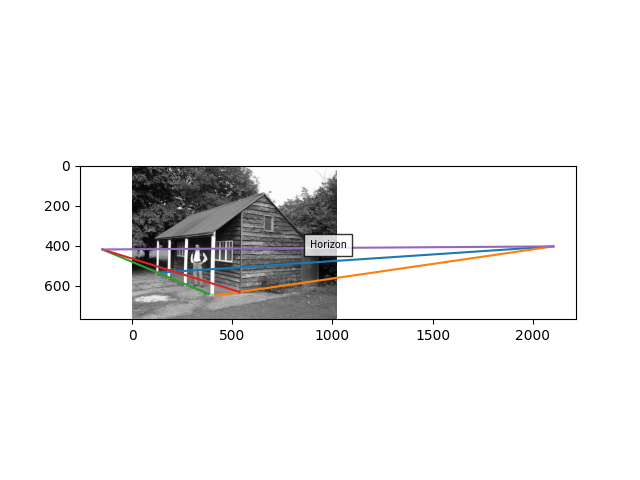

In [4]:
def cross(p1, p2):
    l = np.cross(p1, p2)
    return l / l[-1]

def vanishing_point(l1, l2):
    l = cross(*l1)
    m = cross(*l2)
    return cross(l, m)

def plot_segment(ax, p1, p2, *args, **kwargs):
    (x, y, _), (u, v, _) = p1, p2
    ax.plot((x, u), (y, v), *args, **kwargs)


v_10_11 = vanishing_point(lines[10], lines[11])
v_12_13 = vanishing_point(lines[12], lines[13])


fig, ax = plt.subplots(1, 1)
plt.gray()
ax.imshow(hut, vmin=0, vmax=255);

plot_segment(ax, lines[10][0], v_10_11)
plot_segment(ax, lines[11][0], v_10_11)
plot_segment(ax, lines[12][0], v_12_13)
plot_segment(ax, lines[13][0], v_12_13)


(x, y, _), (u, v, _) = v_10_11, v_12_13
ax.plot((x, u), (y, v))
txt = ax.text((x+u)/2, (y+v)/2, f"Horizon", horizontalalignment='center', size="x-small", va="baseline")
txt.set_bbox({"facecolor": "white", "alpha": 0.8})

horizon_line = (v_10_11, v_12_13)

# Lets measure the Zenith point (or the Nadir)
We have 5 vertical lines, (lines 5 to 9), so lets find a point $z$ such that $l^T z = 0$ for all such lines.

This can be solved through SVD:

In [5]:
L = np.array([cross(*lines[i]) for i in [5, 6, 7, 8, 9]])
L /= np.std(L, axis=1)[:, None]
U, s, Vt = la.svd(L)
zenith = Vt[-1]
zenith /= zenith[-1]
zenith

array([ 2.83059763e+03, -1.02680529e+05,  1.00000000e+00])

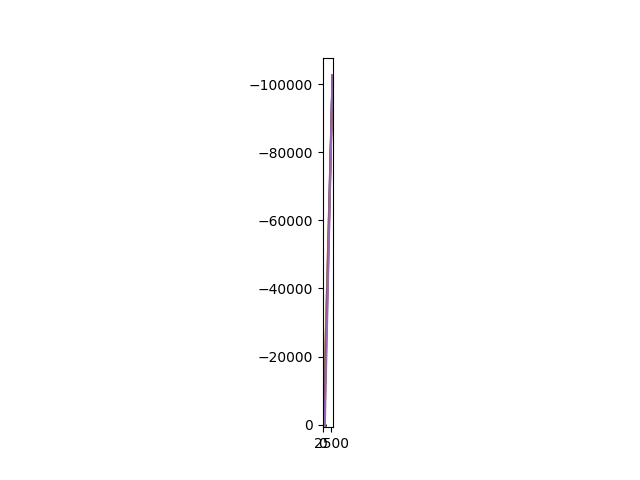

In [6]:
fig, ax = plt.subplots(1, 1)
plt.gray()
ax.imshow(hut, vmin=0, vmax=255);

for i in [5, 6, 7, 8, 9]:
    plot_segment(ax, lines[i][0], zenith)

#ax.set_xlim(0, hut.shape[1])
#ax.set_ylim(hut.shape[0], 0);

## Lets pick a segment for the man's height

We pick a point for the base of the man and connect it to the zenith.

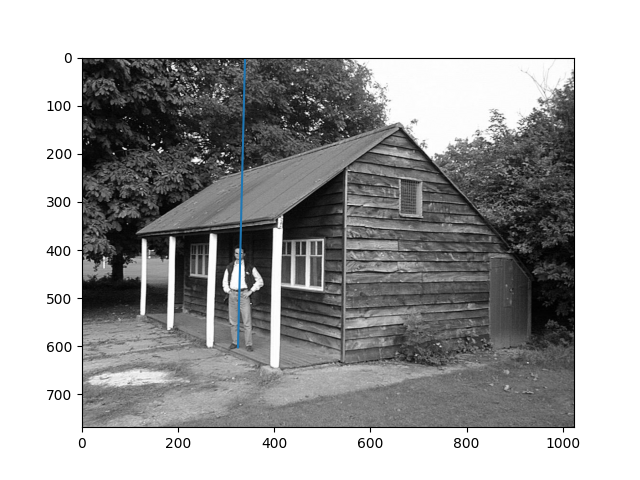

In [7]:
base_man = np.r_[325,  602, 1]

fig, ax = plt.subplots(1, 1)
plt.gray()
ax.imshow(hut, vmin=0, vmax=255);

plot_segment(ax, base_man, zenith)

ax.set_xlim(0, hut.shape[1])
ax.set_ylim(hut.shape[0], 0);

We then pick an appropriate point for the top of the man.

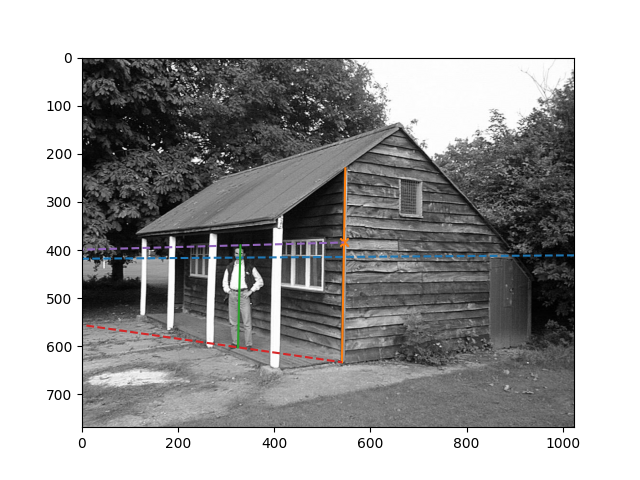

In [8]:
top_man = np.r_[330, 390, 1]

base, top = lines[9]
fig, ax = plt.subplots(1, 1)
plt.gray()
ax.imshow(hut, vmin=0, vmax=255);

# plot horizon line
plot_segment(ax, *horizon_line, "--", c="C0")

# plot segments
plot_segment(ax, base, top, c="C1")
plot_segment(ax, base_man, top_man, c="C2")

# connect bases to horizon line
u = cross(cross(*horizon_line), cross(base_man, base))
plot_segment(ax, u, horizon_line[1], "--", c="C0")
plot_segment(ax, u, lines[9][0], "--", c="C3")
plt.scatter(*u[:2], marker="x")
plt.text(*u[:2], "$u$")

# connect top to u and intersect on segment 9
top_proj = cross(cross(base, top), cross(u, top_man))
plot_segment(ax, u, top_proj, "--", c="C4")
plt.scatter(*top_proj[:2], marker="x");

ax.set_xlim(0, hut.shape[1])
ax.set_ylim(hut.shape[0], 0);

Now we have the projection of the man's height inside the known segment!

Lets correct the projectivity within the line segment.

The distance (in physical space) between the bottom of the known segment and the zenith is infinite,
but the zenith is finite in image space!

In [9]:
distance_zenith = np.sqrt(np.sum((base - zenith)**2))
distance_known  = np.sqrt(np.sum((base - top)**2))
distance_man    = np.sqrt(np.sum((base - top_proj)**2))

distance_man, distance_known, distance_zenith

(248.93588775295706, 403.0607894598531, 103338.89630493228)

We must rectify this projective line by sending the zenith to infinity.

The 1D projective transform that keeps the point $(0, 1)$ in $(0, 1)$ but maps the point $(v, 1)$ to $(1, 0)$ is
$$ \begin{bmatrix} 1 & 0\\ 1 & -v \end{bmatrix}.$$

In [10]:
H = np.array([[1, 0], [1, -distance_zenith]])
H

array([[ 1.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00, -1.03338896e+05]])

In [11]:
def transform(H, p):
    z = H @ p
    return z / z[-1]

In [12]:
d2 = transform(H, [distance_known, 1])
d1 = transform(H, [distance_man, 1])

d1, d2

(array([-0.00241474,  1.        ]), array([-0.00391565,  1.        ]))

In [13]:
ratio = d1[0]/d2[0]
ratio

0.6166903902212139

In [14]:
distance_man/distance_known # should be close since zenith is 'far'

0.6176137552019367

In [15]:
mans_height = ratio * 293.4
mans_height # in centimeters

180.93696049090414